# Amazon Product Reviews Sentiment Analysis — May19 Dataset + VADER + Robust RoBERTa

This notebook uses the Kaggle **Datafiniti Consumer Reviews of Amazon Products** dataset and automatically selects the CSV file whose name contains **`May19`**.

## 1. Install dependencies

Run this once in Colab. If packages are already installed, this cell will be fast.

In [1]:
!pip -q install kagglehub nltk transformers accelerate scikit-learn seaborn pandas numpy matplotlib torch

## 2. Imports

In [2]:
import os
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, label_binarize
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack, csr_matrix

import torch
from torch import nn
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

MAX_ROWS = None #change to smaller dataset for quick run

# Labelling
LABEL_NAMES = ["Negative", "Neutral", "Positive"]
LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# Transformer model - sentiment-aware
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

TRAINING_STRATEGY = "downweight"

OUTPUT_DIR = "amazon_may19_roberta_vader_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3. Download Kaggle dataset and select the May19 CSV

This cell uses `kagglehub` to download the dataset. It then searches for a `.csv` file containing `May19` in its filename.

In [3]:
from google.colab import files
import os

# Upload kaggle.json when prompted
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d datafiniti/consumer-reviews-of-amazon-products
!unzip -q consumer-reviews-of-amazon-products.zip -d data/
!ls data/

Saving 1429_1.csv.zip to 1429_1.csv.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products
License(s): CC-BY-NC-SA-4.0
100% 16.3M/16.3M [00:02<00:00, 8.12MB/s]

1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv("data/1429_1.csv")

print(df_raw.shape)
df_raw.head(3)

/tmp/ipykernel_11309/741440105.py:5: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("data/1429_1.csv")


(34660, 21)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ


## 4. Data Engineering and normalize schema


In [5]:
print("Columns:")
for c in df_raw.columns:
    print(c)

Columns:
id
name
asins
brand
categories
keys
manufacturer
reviews.date
reviews.dateAdded
reviews.dateSeen
reviews.didPurchase
reviews.doRecommend
reviews.id
reviews.numHelpful
reviews.rating
reviews.sourceURLs
reviews.text
reviews.title
reviews.userCity
reviews.userProvince
reviews.username


In [6]:
def find_first_existing_column(df, candidates):
    for c in candidates:
        if c in df_raw.columns:
            return c
    return None

rating_col = find_first_existing_column(
    df_raw,
    ["reviews.rating", "rating", "reviews.rating.value", "review_rating", "stars"]
)
text_col = find_first_existing_column(
    df_raw,
    ["reviews.text", "review_text", "text", "reviews", "body"]
)
title_col = find_first_existing_column(
    df_raw,
    ["reviews.title", "review_title", "title", "summary"]
)
product_col = find_first_existing_column(
    df_raw,
    ["name", "product.name", "products.name", "asins", "id"]
)

essential = {"rating_col": rating_col, "text_col": text_col}
print("Detected columns:", essential)
print("title_col:", title_col)
print("product_col:", product_col)

if rating_col is None or text_col is None:
    raise ValueError("Could not detect rating/text columns. Check df_raw.columns above.")

df = df_raw.copy()

# Normalizing rating
# Some CSVs store ratings as strings; coercion handles this.
df["rating"] = pd.to_numeric(df[rating_col], errors="coerce")

# Normalize text/title
if title_col is None:
    df["review_title"] = ""
else:
    df["review_title"] = df[title_col].fillna("").astype(str)

df["review_body"] = df[text_col].fillna("").astype(str)

# Combine title and body. Title often contains useful sentiment signal.
df["text"] = (df["review_title"].str.strip() + ". " + df["review_body"].str.strip()).str.strip()
df["text"] = df["text"].str.replace(r"^\.\s*", "", regex=True)

if product_col is not None:
    df["product"] = df[product_col].fillna("Unknown").astype(str)
else:
    df["product"] = "Unknown"

df = df.dropna(subset=["rating", "text"]).copy()
df = df[df["text"].str.len() > 5].copy()
df["rating"] = df["rating"].astype(int)
df = df[df["rating"].between(1, 5)].copy()

df = df.reset_index(drop=True)
print("Cleaned shape:", df.shape)
df[["rating", "review_title", "review_body", "text", "product"]].head()

Detected columns: {'rating_col': 'reviews.rating', 'text_col': 'reviews.text'}
title_col: reviews.title
product_col: name
Cleaned shape: (34627, 26)


,rating,review_title,review_body,text,product
0,5,Kindle,This product so far has not disappointed. My c...,Kindle. This product so far has not disappoint...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
1,5,very fast,great for beginner or experienced person. Boug...,very fast. great for beginner or experienced p...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
2,5,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.. Inexp...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
3,4,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Good!!!. I've had my Fire HD 8 two weeks now a...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
4,5,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,Fantastic Tablet for kids. I bought this for m...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."


## 5. Create weak sentiment labels from star ratings

This is the common mapping:

- 1–2 stars → Negative
- 3 stars → Neutral / Mixed
- 4–5 stars → Positive

Important: these are **weak labels**. A 2-star review can still contain positive text, and a 5-star review can contain complaints. That is exactly why we add VADER auditing.

star_label_name
Positive    32316
Neutral      1499
Negative      812
Name: count, dtype: int64


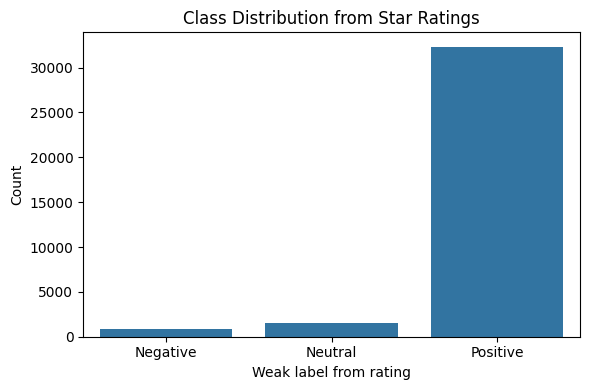

In [7]:
def rating_to_label_id(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral / Mixed
    else:
        return 2  # Positive


df["star_label"] = df["rating"].apply(rating_to_label_id).astype(int)
df["star_label_name"] = df["star_label"].map(ID2LABEL)

print(df["star_label_name"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="star_label_name", order=LABEL_NAMES)
plt.title("Class Distribution from Star Ratings")
plt.xlabel("Weak label from rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. VADER sentiment analysis

VADER is a lexicon + rule-based sentiment method. It returns `neg`, `neu`, `pos`, and `compound` scores.

We use VADER in two ways:

1. **Baseline classifier** using default VADER thresholds.
2. **Label-quality auditor** using stricter thresholds to detect strong contradictions.

In [8]:
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

vader_scores = df["text"].apply(lambda x: sia.polarity_scores(str(x)))
vader_df = pd.json_normalize(vader_scores)
vader_df.columns = [f"vader_{c}" for c in vader_df.columns]

df = pd.concat([df, vader_df], axis=1)

def vader_label_default(compound):
    # Common VADER convention
    if compound >= 0.05:
        return 2
    elif compound <= -0.05:
        return 0
    else:
        return 1


def vader_label_strict(compound):
    # Stricter threshold used for contradiction detection.
    # This avoids treating weak VADER signals as strong evidence.
    if compound >= 0.35:
        return 2
    elif compound <= -0.35:
        return 0
    else:
        return 1


df["vader_label"] = df["vader_compound"].apply(vader_label_default).astype(int)
df["vader_label_name"] = df["vader_label"].map(ID2LABEL)

df["vader_strict_label"] = df["vader_compound"].apply(vader_label_strict).astype(int)
df["vader_strict_label_name"] = df["vader_strict_label"].map(ID2LABEL)

df[["rating", "star_label_name", "vader_compound", "vader_label_name", "text"]].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,rating,star_label_name,vader_compound,vader_label_name,text
0,5,Positive,0.9194,Positive,Kindle. This product so far has not disappoint...
1,5,Positive,0.8996,Positive,very fast. great for beginner or experienced p...
2,5,Positive,0.4404,Positive,Beginner tablet for our 9 year old son.. Inexp...
3,4,Positive,0.9892,Positive,Good!!!. I've had my Fire HD 8 two weeks now a...
4,5,Positive,0.8500,Positive,Fantastic Tablet for kids. I bought this for m...


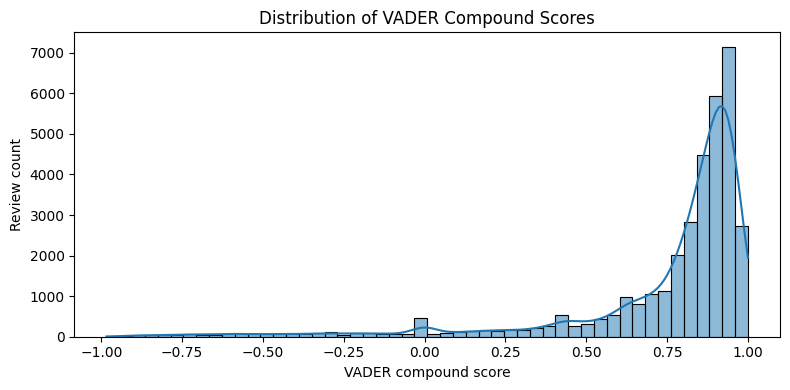

VADER default labels:
vader_label_name
Positive    32660
Negative     1422
Neutral       545
Name: count, dtype: int64
VADER strict labels:
vader_strict_label_name
Positive    31572
Neutral      2236
Negative      819
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["vader_compound"], bins=50, kde=True)
plt.title("Distribution of VADER Compound Scores")
plt.xlabel("VADER compound score")
plt.ylabel("Review count")
plt.tight_layout()
plt.show()

print("VADER default labels:")
print(df["vader_label_name"].value_counts())

print("VADER strict labels:")
print(df["vader_strict_label_name"].value_counts())

## 7. Star-rating label vs VADER contradiction audit

This is the key innovation for your observation:

> star is 2 but positive review is given

We explicitly flag these cases instead of blindly training on them.

conflict_type
agree                       30930
star_polar_text_mixed        1887
neutral_star_strong_text     1150
high_star_negative_text       379
low_star_positive_text        281
Name: count, dtype: int64


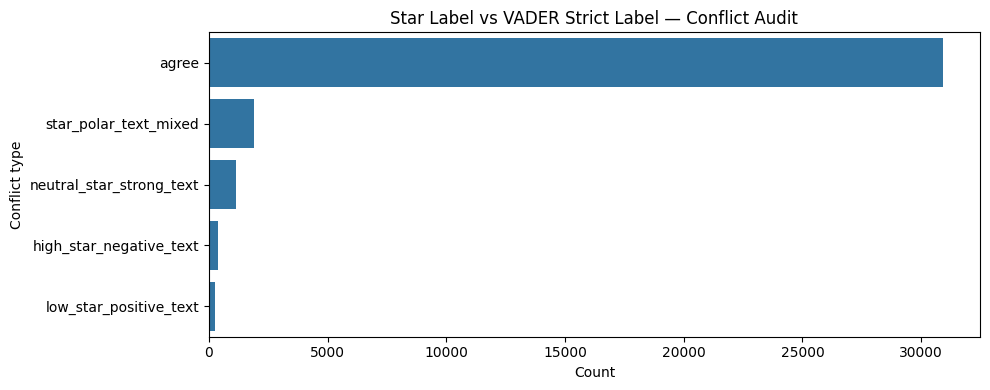

In [10]:
def conflict_type(row):
    star = row["star_label"]
    vader = row["vader_strict_label"]
    compound = row["vader_compound"]

    if star == vader:
        return "agree"
    if star == 0 and vader == 2:
        return "low_star_positive_text"
    if star == 2 and vader == 0:
        return "high_star_negative_text"
    if star == 1 and vader in [0, 2]:
        return "neutral_star_strong_text"
    if star in [0, 2] and vader == 1:
        return "star_polar_text_mixed"
    return "other_conflict"


df["conflict_type"] = df.apply(conflict_type, axis=1)
df["star_vader_agree"] = df["conflict_type"].eq("agree")

conflict_counts = df["conflict_type"].value_counts()
print(conflict_counts)

plt.figure(figsize=(10, 4))
sns.countplot(
    data=df,
    y="conflict_type",
    order=conflict_counts.index
)
plt.title("Star Label vs VADER Strict Label — Conflict Audit")
plt.xlabel("Count")
plt.ylabel("Conflict type")
plt.tight_layout()
plt.show()

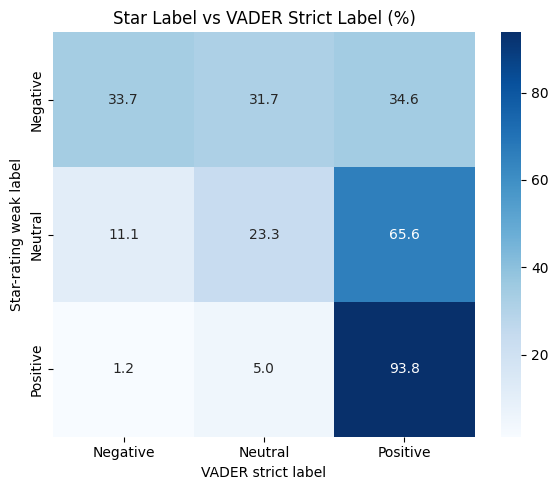

Counts:
          Negative  Neutral  Positive
Negative       274      257       281
Neutral        166      349       984
Positive       379     1630     30307


In [11]:
# Confusion matrix between star labels and VADER strict labels
cm_sv = confusion_matrix(df["star_label"], df["vader_strict_label"], labels=[0, 1, 2])
cm_sv_pct = cm_sv / cm_sv.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_sv_pct,
    annot=True,
    fmt=".1f",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cmap="Blues"
)
plt.title("Star Label vs VADER Strict Label (%)")
plt.xlabel("VADER strict label")
plt.ylabel("Star-rating weak label")
plt.tight_layout()
plt.show()

print("Counts:")
print(pd.DataFrame(cm_sv, index=LABEL_NAMES, columns=LABEL_NAMES))

In [12]:
# Show exact examples of the problem you observed.
examples_low_star_positive = df[df["conflict_type"] == "low_star_positive_text"][
    ["rating", "star_label_name", "vader_compound", "vader_strict_label_name", "review_title", "review_body"]
].head(20)

examples_high_star_negative = df[df["conflict_type"] == "high_star_negative_text"][
    ["rating", "star_label_name", "vader_compound", "vader_strict_label_name", "review_title", "review_body"]
].head(20)

print("Low star but positive text examples:")
display(examples_low_star_positive)

print("High star but negative text examples:")
display(examples_high_star_negative)

Low star but positive text examples:


,rating,star_label_name,vader_compound,vader_strict_label_name,review_title,review_body
117,2,Negative,0.4404,Positive,Wasn't for me,Didn't have some of the features I was looking...
338,1,Negative,0.4110,Positive,Ads ads and ads,"If ads dont bother you, then this may be a dec..."
444,2,Negative,0.9081,Positive,It is a shopping device,"If you shop on Amazon all the time, this will ..."
446,2,Negative,0.7479,Positive,great little device,fire tablet is very powerful for the size and ...
649,2,Negative,0.7212,Positive,Not What She Wanted,My wife wanted an iPad. I bought her this beca...
727,1,Negative,0.9914,Positive,NOT WORTH IT,I went with this tablet based on many good cus...
751,2,Negative,0.4885,Positive,Returned it.. SLOW!!!,We purchased this as a replacement for our now...
1282,2,Negative,0.4603,Positive,Color difference is HUGE. Bad customer service.,I got a magenta color because I loved the beau...
1474,1,Negative,0.5229,Positive,non functional!!!,horrible...just like the other 7 i have owned ...
2239,2,Negative,0.7579,Positive,FireHD 8,The headphone jack restarts the tablet when yo...


High star but negative text examples:


,rating,star_label_name,vader_compound,vader_strict_label_name,review_title,review_body
108,4,Positive,-0.7743,Negative,Disappointed no access to Apps without credit ...,Great tablet but apps limited comparison of ot...
159,5,Positive,-0.4256,Negative,jealous,I got this for my mom for Christmas. Every tim...
497,4,Positive,-0.4821,Negative,One flaw,Not sure if this is due to the new version but...
499,4,Positive,-0.4678,Negative,"Great, but awaiting Alexa feature",Still waiting for Alexa to function. Several c...
556,4,Positive,-0.7096,Negative,I like the Kindle Fire very much.,My only disappointment is the inability to dow...
689,4,Positive,-0.6808,Negative,Works fine,I exchanged a highly unsatisfactory Insignia u...
902,4,Positive,-0.5549,Negative,Good value,This is my third Kindle. My sister bought me m...
941,4,Positive,-0.5883,Negative,Fire HD tablet,"I bought this to replace a 7""fire hd tablet th..."
969,5,Positive,-0.4727,Negative,Excellent buy!,Pros - HD quality for low price. Works really ...
977,5,Positive,-0.4374,Negative,Kindle/Amazon Fire,I bought this tablet for my sister to replace ...


## 8. VADER baseline evaluation


VADER Baseline vs Star Labels
Accuracy         : 0.9129
Balanced accuracy: 0.4923
Macro F1         : 0.4567
Weighted F1      : 0.9062
MCC              : 0.2644
Classification report:
              precision    recall  f1-score   support

    Negative     0.2630    0.4606    0.3348       812
     Neutral     0.1431    0.0520    0.0763      1499
    Positive     0.9540    0.9642    0.9591     32316

    accuracy                         0.9129     34627
   macro avg     0.4534    0.4923    0.4567     34627
weighted avg     0.9027    0.9129    0.9062     34627



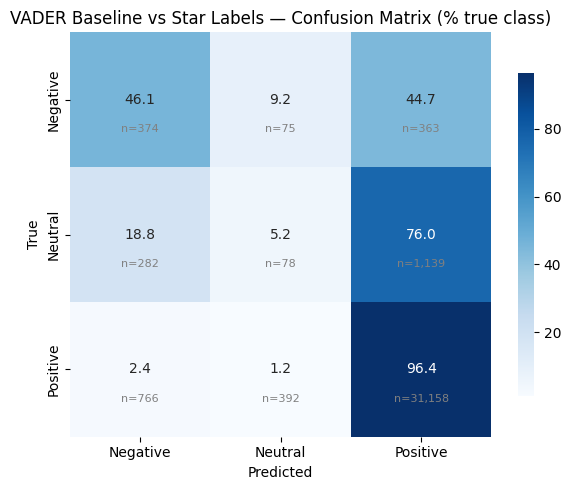

In [13]:
def evaluate_predictions(y_true, y_pred, title="Evaluation"):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print("Accuracy         :", round(accuracy_score(y_true, y_pred), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y_true, y_pred), 4))
    print("Macro F1         :", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("Weighted F1      :", round(f1_score(y_true, y_pred, average="weighted"), 4))
    print("MCC              :", round(matthews_corrcoef(y_true, y_pred), 4))
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        cm_pct,
        annot=True,
        fmt=".1f",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        cmap="Blues",
        cbar_kws={"shrink": 0.8}
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.72, f"n={cm[i, j]:,}", ha="center", va="center", fontsize=8, color="gray")
    plt.title(title + " — Confusion Matrix (% true class)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


evaluate_predictions(df["star_label"], df["vader_label"], title="VADER Baseline vs Star Labels")

## 9. Build sample weights for noisy labels and class imbalance

We create two kinds of weights:

1. **Class weights**: compensate for class imbalance.
2. **Label-quality weights**: reduce the influence of strong star/VADER contradictions.

This directly addresses misclassification and class imbalance more robustly than only reporting accuracy.

In [14]:
def quality_weight(conflict):
    if conflict == "agree":
        return 1.0
    if conflict in ["star_polar_text_mixed", "neutral_star_strong_text"]:
        return 0.7
    if conflict in ["low_star_positive_text", "high_star_negative_text"]:
        return 0.3
    return 0.5


df["quality_weight"] = df["conflict_type"].apply(quality_weight).astype(float)

# Class-balanced weights: inverse frequency normalized around 1.0
class_counts = df["star_label"].value_counts().sort_index()
class_weights = len(df) / (len(class_counts) * class_counts)
class_weights = class_weights.sort_index()
print("Class counts:")
print(class_counts)
print("Class weights:")
print(class_weights)

class_weight_map = class_weights.to_dict()
df["class_weight"] = df["star_label"].map(class_weight_map).astype(float)

df["sample_weight"] = df["quality_weight"] * df["class_weight"]

print(df[["star_label_name", "conflict_type", "quality_weight", "class_weight", "sample_weight"]].head())
print("Sample weight summary:")
print(df["sample_weight"].describe())

Class counts:
star_label
0      812
1     1499
2    32316
Name: count, dtype: int64
Class weights:
star_label
0    14.214696
1     7.700022
2     0.357171
Name: count, dtype: float64
  star_label_name conflict_type  quality_weight  class_weight  sample_weight
0        Positive         agree             1.0      0.357171       0.357171
1        Positive         agree             1.0      0.357171       0.357171
2        Positive         agree             1.0      0.357171       0.357171
3        Positive         agree             1.0      0.357171       0.357171
4        Positive         agree             1.0      0.357171       0.357171
Sample weight summary:
count    34627.000000
mean         0.803104
std          1.874447
min          0.107151
25%          0.357171
50%          0.357171
75%          0.357171
max         14.214696
Name: sample_weight, dtype: float64


## 10. Train/validation/test split

We split by the weak star label, but keep the conflict metadata for analysis.

If `TRAINING_STRATEGY = "drop_strong_conflicts"`, strong contradictions are dropped from the **training set only**, not from validation/test. That gives a fairer evaluation on real-world messy data.

In [15]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["star_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["star_label"]
)

if TRAINING_STRATEGY == "drop_strong_conflicts":
    strong_conflicts = ["low_star_positive_text", "high_star_negative_text"]
    before = len(train_df)
    train_df = train_df[~train_df["conflict_type"].isin(strong_conflicts)].copy()
    print(f"Dropped {before - len(train_df):,} strong-conflict rows from training.")

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("", name)
    print(part["star_label_name"].value_counts(normalize=True).round(3))

Train: (24238, 41)
Val  : (5194, 41)
Test : (5195, 41)
 train
star_label_name
Positive    0.933
Neutral     0.043
Negative    0.023
Name: proportion, dtype: float64
 val
star_label_name
Positive    0.933
Neutral     0.043
Negative    0.023
Name: proportion, dtype: float64
 test
star_label_name
Positive    0.933
Neutral     0.043
Negative    0.023
Name: proportion, dtype: float64


## 11. Strong baseline: TF-IDF + Logistic Regression + VADER features

This is a strong, explainable baseline. It is much faster than transformers and usually better than VADER alone.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Validation — TF-IDF + VADER Logistic Regression
Accuracy         : 0.9114
Balanced accuracy: 0.6725
Macro F1         : 0.6094
Weighted F1      : 0.9216
MCC              : 0.4528
Classification report:
              precision    recall  f1-score   support

    Negative     0.4491    0.6198    0.5208       121
     Neutral     0.2822    0.4578    0.3492       225
    Positive     0.9773    0.9398    0.9581      4848

    accuracy                         0.9114      5194
   macro avg     0.5695    0.6725    0.6094      5194
weighted avg     0.9348    0.9114    0.9216      5194



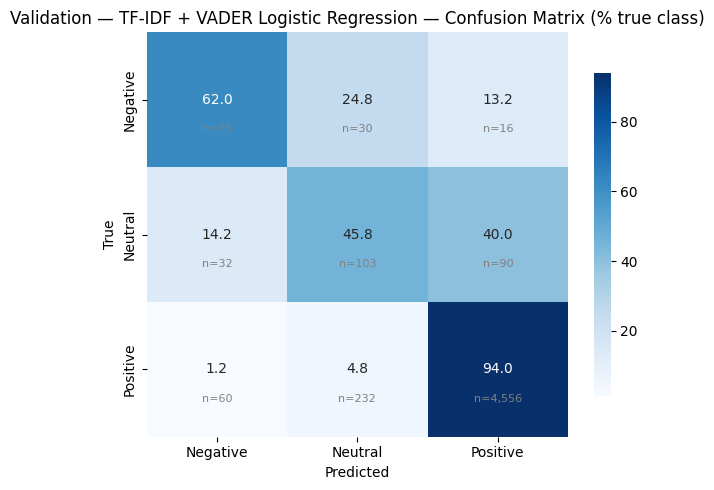

Test — TF-IDF + VADER Logistic Regression
Accuracy         : 0.9091
Balanced accuracy: 0.6874
Macro F1         : 0.6156
Weighted F1      : 0.9202
MCC              : 0.4537
Classification report:
              precision    recall  f1-score   support

    Negative     0.4629    0.6639    0.5455       122
     Neutral     0.2751    0.4622    0.3449       225
    Positive     0.9776    0.9361    0.9564      4848

    accuracy                         0.9091      5195
   macro avg     0.5719    0.6874    0.6156      5195
weighted avg     0.9351    0.9091    0.9202      5195



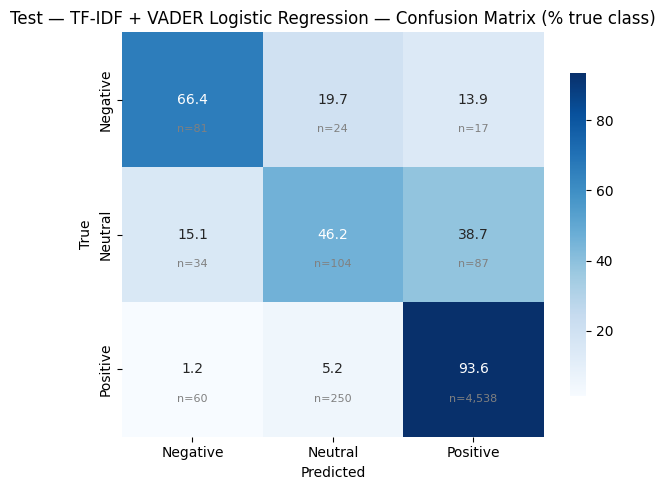

In [16]:
class TfidfVaderModel:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents="unicode"
        )
        self.clf = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            n_jobs=-1,
            C=2.0,
            multi_class="auto"
        )

    def _features(self, frame, fit=False):
        text = frame["text"].fillna("").astype(str)
        vader_features = frame[["vader_neg", "vader_neu", "vader_pos", "vader_compound"]].values
        vader_sparse = csr_matrix(vader_features)

        if fit:
            x_text = self.vectorizer.fit_transform(text)
        else:
            x_text = self.vectorizer.transform(text)

        return hstack([x_text, vader_sparse])

    def fit(self, frame, y):
        X = self._features(frame, fit=True)
        self.clf.fit(X, y)
        return self

    def predict(self, frame):
        X = self._features(frame, fit=False)
        return self.clf.predict(X)

    def predict_proba(self, frame):
        X = self._features(frame, fit=False)
        return self.clf.predict_proba(X)


tfidf_vader = TfidfVaderModel()
tfidf_vader.fit(train_df, train_df["star_label"])

val_pred_lr = tfidf_vader.predict(val_df)
test_pred_lr = tfidf_vader.predict(test_df)
test_prob_lr = tfidf_vader.predict_proba(test_df)

evaluate_predictions(val_df["star_label"], val_pred_lr, title="Validation — TF-IDF + VADER Logistic Regression")
evaluate_predictions(test_df["star_label"], test_pred_lr, title="Test — TF-IDF + VADER Logistic Regression")

## 12. Transformer dataset and tokenizer

This uses RoBERTa with the same 3 labels: Negative, Neutral, Positive.

In [17]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class ReviewDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length=192):
        self.texts = frame["text"].fillna("").astype(str).tolist()
        self.labels = frame["star_label"].astype(int).tolist()
        self.sample_weights = frame["sample_weight"].astype(float).tolist()
        self.conflict_types = frame["conflict_type"].astype(str).tolist()
        self.ratings = frame["rating"].astype(int).tolist()
        self.max_length = max_length
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors=None,
        )
        enc["labels"] = self.labels[idx]
        enc["sample_weight"] = float(self.sample_weights[idx])
        return enc


train_dataset = ReviewDataset(train_df, tokenizer)
val_dataset = ReviewDataset(val_df, tokenizer)
test_dataset = ReviewDataset(test_df, tokenizer)

print(len(train_dataset), len(val_dataset), len(test_dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

24238 5194 5195


## 13. Custom weighted trainer

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

# Class weights from training set only
train_class_counts = train_df["star_label"].value_counts().sort_index()
train_class_weights = len(train_df) / (len(train_class_counts) * train_class_counts)
class_weights_tensor = torch.tensor(
    [train_class_weights.get(i, 1.0) for i in range(3)],
    dtype=torch.float
)
print("Training class weights:", class_weights_tensor)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        sample_weight = inputs.pop("sample_weight", None)

        outputs = model(**inputs)
        logits = outputs.logits

        weights = class_weights_tensor.to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights, reduction="none", label_smoothing=0.05)
        losses = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        if sample_weight is not None:
            sample_weight = sample_weight.to(logits.device).float().view(-1)
            losses = losses * sample_weight

        loss = losses.mean()
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "mcc": matthews_corrcoef(labels, preds),
    }

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training class weights: tensor([14.1992,  7.7019,  0.3572])


## 14. Train RoBERTa

For Colab GPU, start with 2–3 epochs. If overfitting appears, reduce epochs or use stronger regularization.

In [ ]:
import math
import inspect
import torch

from transformers import (
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer
)

# 1. Data collator

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 2. Training setup

num_epochs = 3
train_batch_size = 16
eval_batch_size = 32

steps_per_epoch = math.ceil(len(train_dataset) / train_batch_size)
total_training_steps = steps_per_epoch * num_epochs
warmup_steps = int(0.06 * total_training_steps)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)


# 3. Handle eval_strategy / evaluation_strategy compatibility

training_args_params = inspect.signature(TrainingArguments.__init__).parameters

strategy_arg_name = (
    "eval_strategy"
    if "eval_strategy" in training_args_params
    else "evaluation_strategy"
)

training_args_kwargs = {
    "output_dir": OUTPUT_DIR,
    strategy_arg_name: "epoch",
    "save_strategy": "epoch",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": train_batch_size,
    "per_device_eval_batch_size": eval_batch_size,
    "num_train_epochs": num_epochs,
    "weight_decay": 0.01,
    "warmup_steps": warmup_steps,
    "logging_steps": 50,
    "load_best_model_at_end": True,
    "metric_for_best_model": "macro_f1",
    "greater_is_better": True,
    "save_total_limit": 2,
    "report_to": "none",
    "fp16": torch.cuda.is_available(),
    "seed": SEED,
}

training_args = TrainingArguments(**training_args_kwargs)

# 4. Build Trainer arguments safely


trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": train_dataset,
    "eval_dataset": val_dataset,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
    "callbacks": [
        EarlyStoppingCallback(early_stopping_patience=2)
    ],
}

# Newer Transformers uses processing_class instead of tokenizer.
# Older Transformers used tokenizer.
trainer_params = inspect.signature(Trainer.__init__).parameters

if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer

# 5. Create trainer

trainer = WeightedTrainer(**trainer_kwargs)

# 6. Train

train_result = trainer.train()

# 7. Evaluate

val_metrics = trainer.evaluate()
print("\nValidation metrics:")
print(val_metrics)

# 8. Save model

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nTraining completed.")
print("Model saved to:", OUTPUT_DIR)

Train samples: 24238
Validation samples: 5194
Steps per epoch: 1515
Total training steps: 4545
Warmup steps: 272


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


## 15. Evaluate RoBERTa on validation and test sets

In [ ]:
def softmax_np(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)

val_out = trainer.predict(val_dataset)
test_out = trainer.predict(test_dataset)

val_probs = softmax_np(val_out.predictions)
test_probs = softmax_np(test_out.predictions)

val_preds = val_probs.argmax(axis=1)
test_preds = test_probs.argmax(axis=1)

y_val = val_df["star_label"].values
y_test = test_df["star_label"].values

evaluate_predictions(y_val, val_preds, title="Validation — Weighted RoBERTa")
evaluate_predictions(y_test, test_preds, title="Test — Weighted RoBERTa")

## 16. ROC and precision-recall curves

For imbalanced data, PR curves are often more informative than ROC curves.

In [ ]:
def plot_roc_pr(y_true, probs, title_prefix="Model"):
    y_bin = label_binarize(y_true, classes=[0, 1, 2])

    plt.figure(figsize=(7, 5))
    for i, name in enumerate(LABEL_NAMES):
        if y_bin[:, i].sum() == 0 or y_bin[:, i].sum() == len(y_bin):
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc = roc_auc_score(y_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", alpha=0.5)
    plt.title(f"{title_prefix} — ROC One-vs-Rest")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    for i, name in enumerate(LABEL_NAMES):
        if y_bin[:, i].sum() == 0:
            continue
        precision, recall, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
        ap = average_precision_score(y_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")
    plt.title(f"{title_prefix} — Precision-Recall One-vs-Rest")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_roc_pr(y_test, test_probs, title_prefix="Weighted RoBERTa Test")

## 17. Hard-error analysis


In [ ]:
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df["pred_label"] = test_preds
analysis_df["pred_label_name"] = analysis_df["pred_label"].map(ID2LABEL)
analysis_df["true_label_name"] = analysis_df["star_label"].map(ID2LABEL)
analysis_df["pred_confidence"] = test_probs.max(axis=1)
analysis_df["correct"] = analysis_df["pred_label"].eq(analysis_df["star_label"])

for i, name in enumerate(LABEL_NAMES):
    analysis_df[f"prob_{name}"] = test_probs[:, i]

hard_errors = analysis_df[~analysis_df["correct"]].sort_values("pred_confidence", ascending=False)

print("Total test samples:", len(analysis_df))
print("Wrong predictions:", len(hard_errors))
print("High-confidence wrong predictions >= 0.80:", (hard_errors["pred_confidence"] >= 0.80).sum())

hard_errors[[
    "rating", "true_label_name", "pred_label_name", "pred_confidence",
    "vader_compound", "vader_strict_label_name", "conflict_type",
    "review_title", "review_body"
]].head(30)

In [ ]:
# Error rate by conflict type
error_by_conflict = (
    analysis_df
    .assign(error=~analysis_df["correct"])
    .groupby("conflict_type")
    .agg(
        n=("correct", "size"),
        error_rate=("error", "mean"),
        avg_confidence=("pred_confidence", "mean")
    )
    .sort_values("error_rate", ascending=False)
)

print(error_by_conflict)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=error_by_conflict.reset_index(),
    y="conflict_type",
    x="error_rate"
)
plt.title("Model Error Rate by Star/VADER Conflict Type")
plt.xlabel("Error rate")
plt.ylabel("Conflict type")
plt.tight_layout()
plt.show()

## 18. Save outputs


In [ ]:
audited_path = Path(OUTPUT_DIR) / "amazon_may19_audited_with_vader.csv"
pred_path = Path(OUTPUT_DIR) / "amazon_may19_test_predictions_roberta_vader.csv"

df.to_csv(audited_path, index=False)
analysis_df.to_csv(pred_path, index=False)

trainer.save_model(Path(OUTPUT_DIR) / "best_roberta_model")
tokenizer.save_pretrained(Path(OUTPUT_DIR) / "best_roberta_model")

print("Saved audited data to:", audited_path)
print("Saved predictions to:", pred_path)
print("Saved model to:", Path(OUTPUT_DIR) / "best_roberta_model")

## 19. Inference function for go-to sentiment analysis

Use this after training to score new reviews.

In [ ]:
def predict_sentiment(texts, model=trainer.model, tokenizer=tokenizer, max_length=192):
    if isinstance(texts, str):
        texts = [texts]

    device = next(model.parameters()).device
    model.eval()

    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    preds = probs.argmax(axis=1)

    rows = []
    for text, pred, prob in zip(texts, preds, probs):
        vader = sia.polarity_scores(text)
        rows.append({
            "text": text,
            "model_sentiment": ID2LABEL[int(pred)],
            "model_confidence": float(prob[pred]),
            "prob_negative": float(prob[0]),
            "prob_neutral": float(prob[1]),
            "prob_positive": float(prob[2]),
            "vader_compound": vader["compound"],
            "vader_neg": vader["neg"],
            "vader_neu": vader["neu"],
            "vader_pos": vader["pos"],
        })

    return pd.DataFrame(rows)


predict_sentiment([
    "The device looks good and the screen is nice, but the battery died after two days.",
    "Excellent product, works perfectly and setup was easy.",
    "It is okay, not great, not terrible."
])

## 20. Interpretation

Use this framing in your project/report:

> The rating is treated as a weak supervision signal rather than ground truth. Because review text and star ratings can contradict each other, I used VADER as an interpretable lexical sentiment auditor. Strong rating-text contradictions were explicitly identified, inspected, and either down-weighted or removed from the training set. Final performance was evaluated not only with accuracy, but also macro F1, balanced accuracy, MCC, confusion matrices, PR curves, and hard-error analysis. This makes the pipeline more robust to class imbalance and noisy labels.

Best practical model recommendation:

- **Fast baseline:** VADER only
- **Strong explainable baseline:** TF-IDF + Logistic Regression + VADER scores
- **Best go-to model:** RoBERTa sentiment model fine-tuned with class weights and VADER-based noisy-label down-weighting

In [ ]:
from google.colab import files
import shutil
from pathlib import Path

# Change this if your folder name/path is different
folder_path = Path("/content/amazon_may19_roberta_vader_output")

# Check folder exists
if not folder_path.exists():
    raise FileNotFoundError(f"Folder not found: {folder_path}")

# Create zip file
zip_path = shutil.make_archive(
    base_name=str(folder_path),
    format="zip",
    root_dir=str(folder_path)
)

print("Created zip file:", zip_path)

# Download zip
files.download(zip_path)